K-NN ALGORITHM

768
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
0      148.0
1       85.0
2      183.0
3       89.0
4      137.0
       ...  
763    101.0
764    122.0
765    121.0
766    126.0
767     93.0
Name: Glucose, Length: 768, dtype: float64


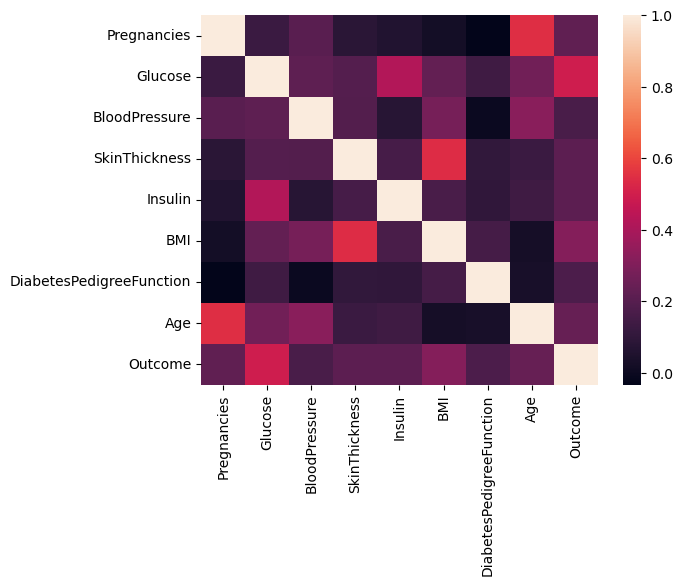

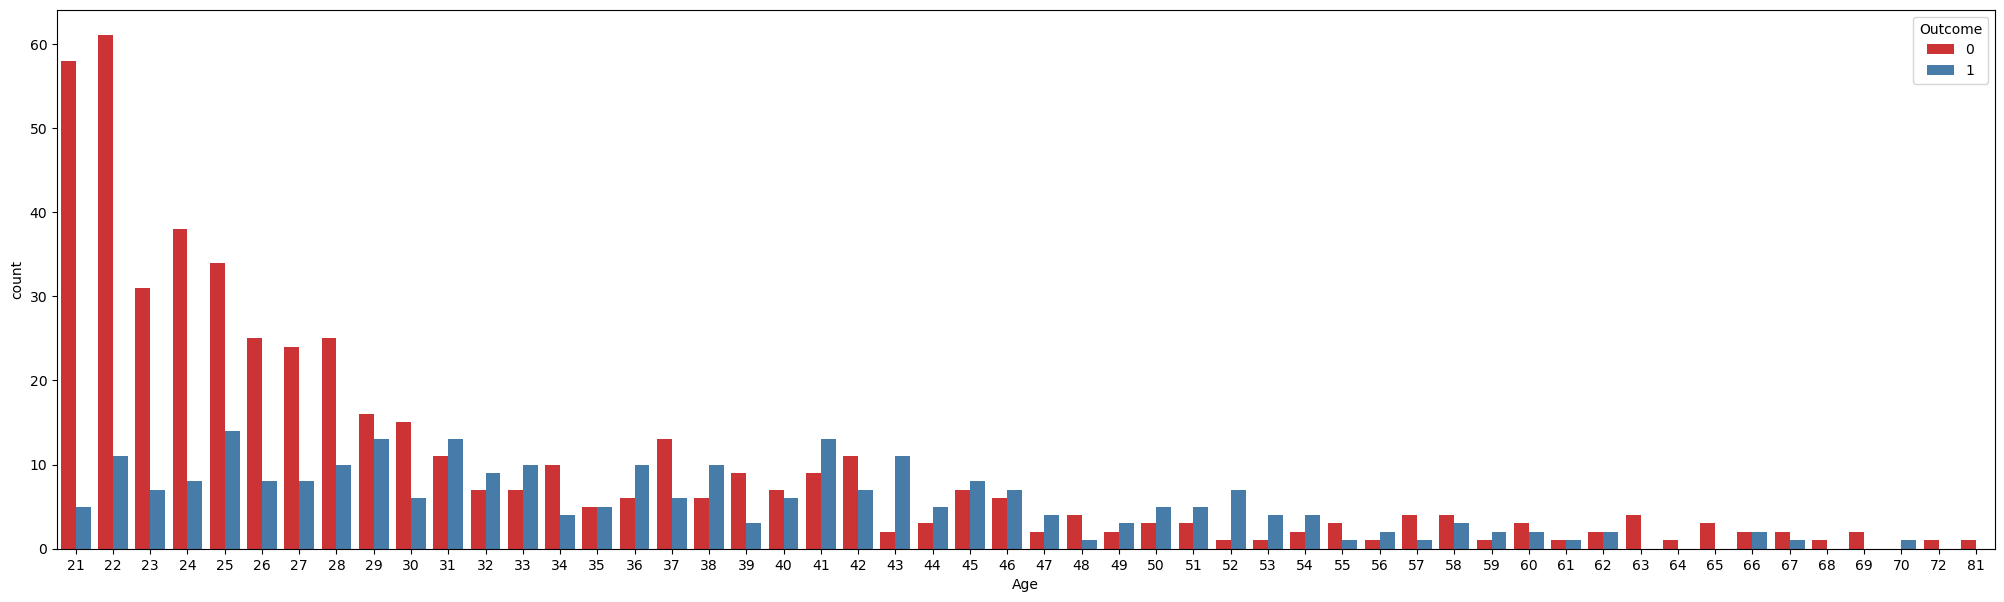

C:\Users\KIIT\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


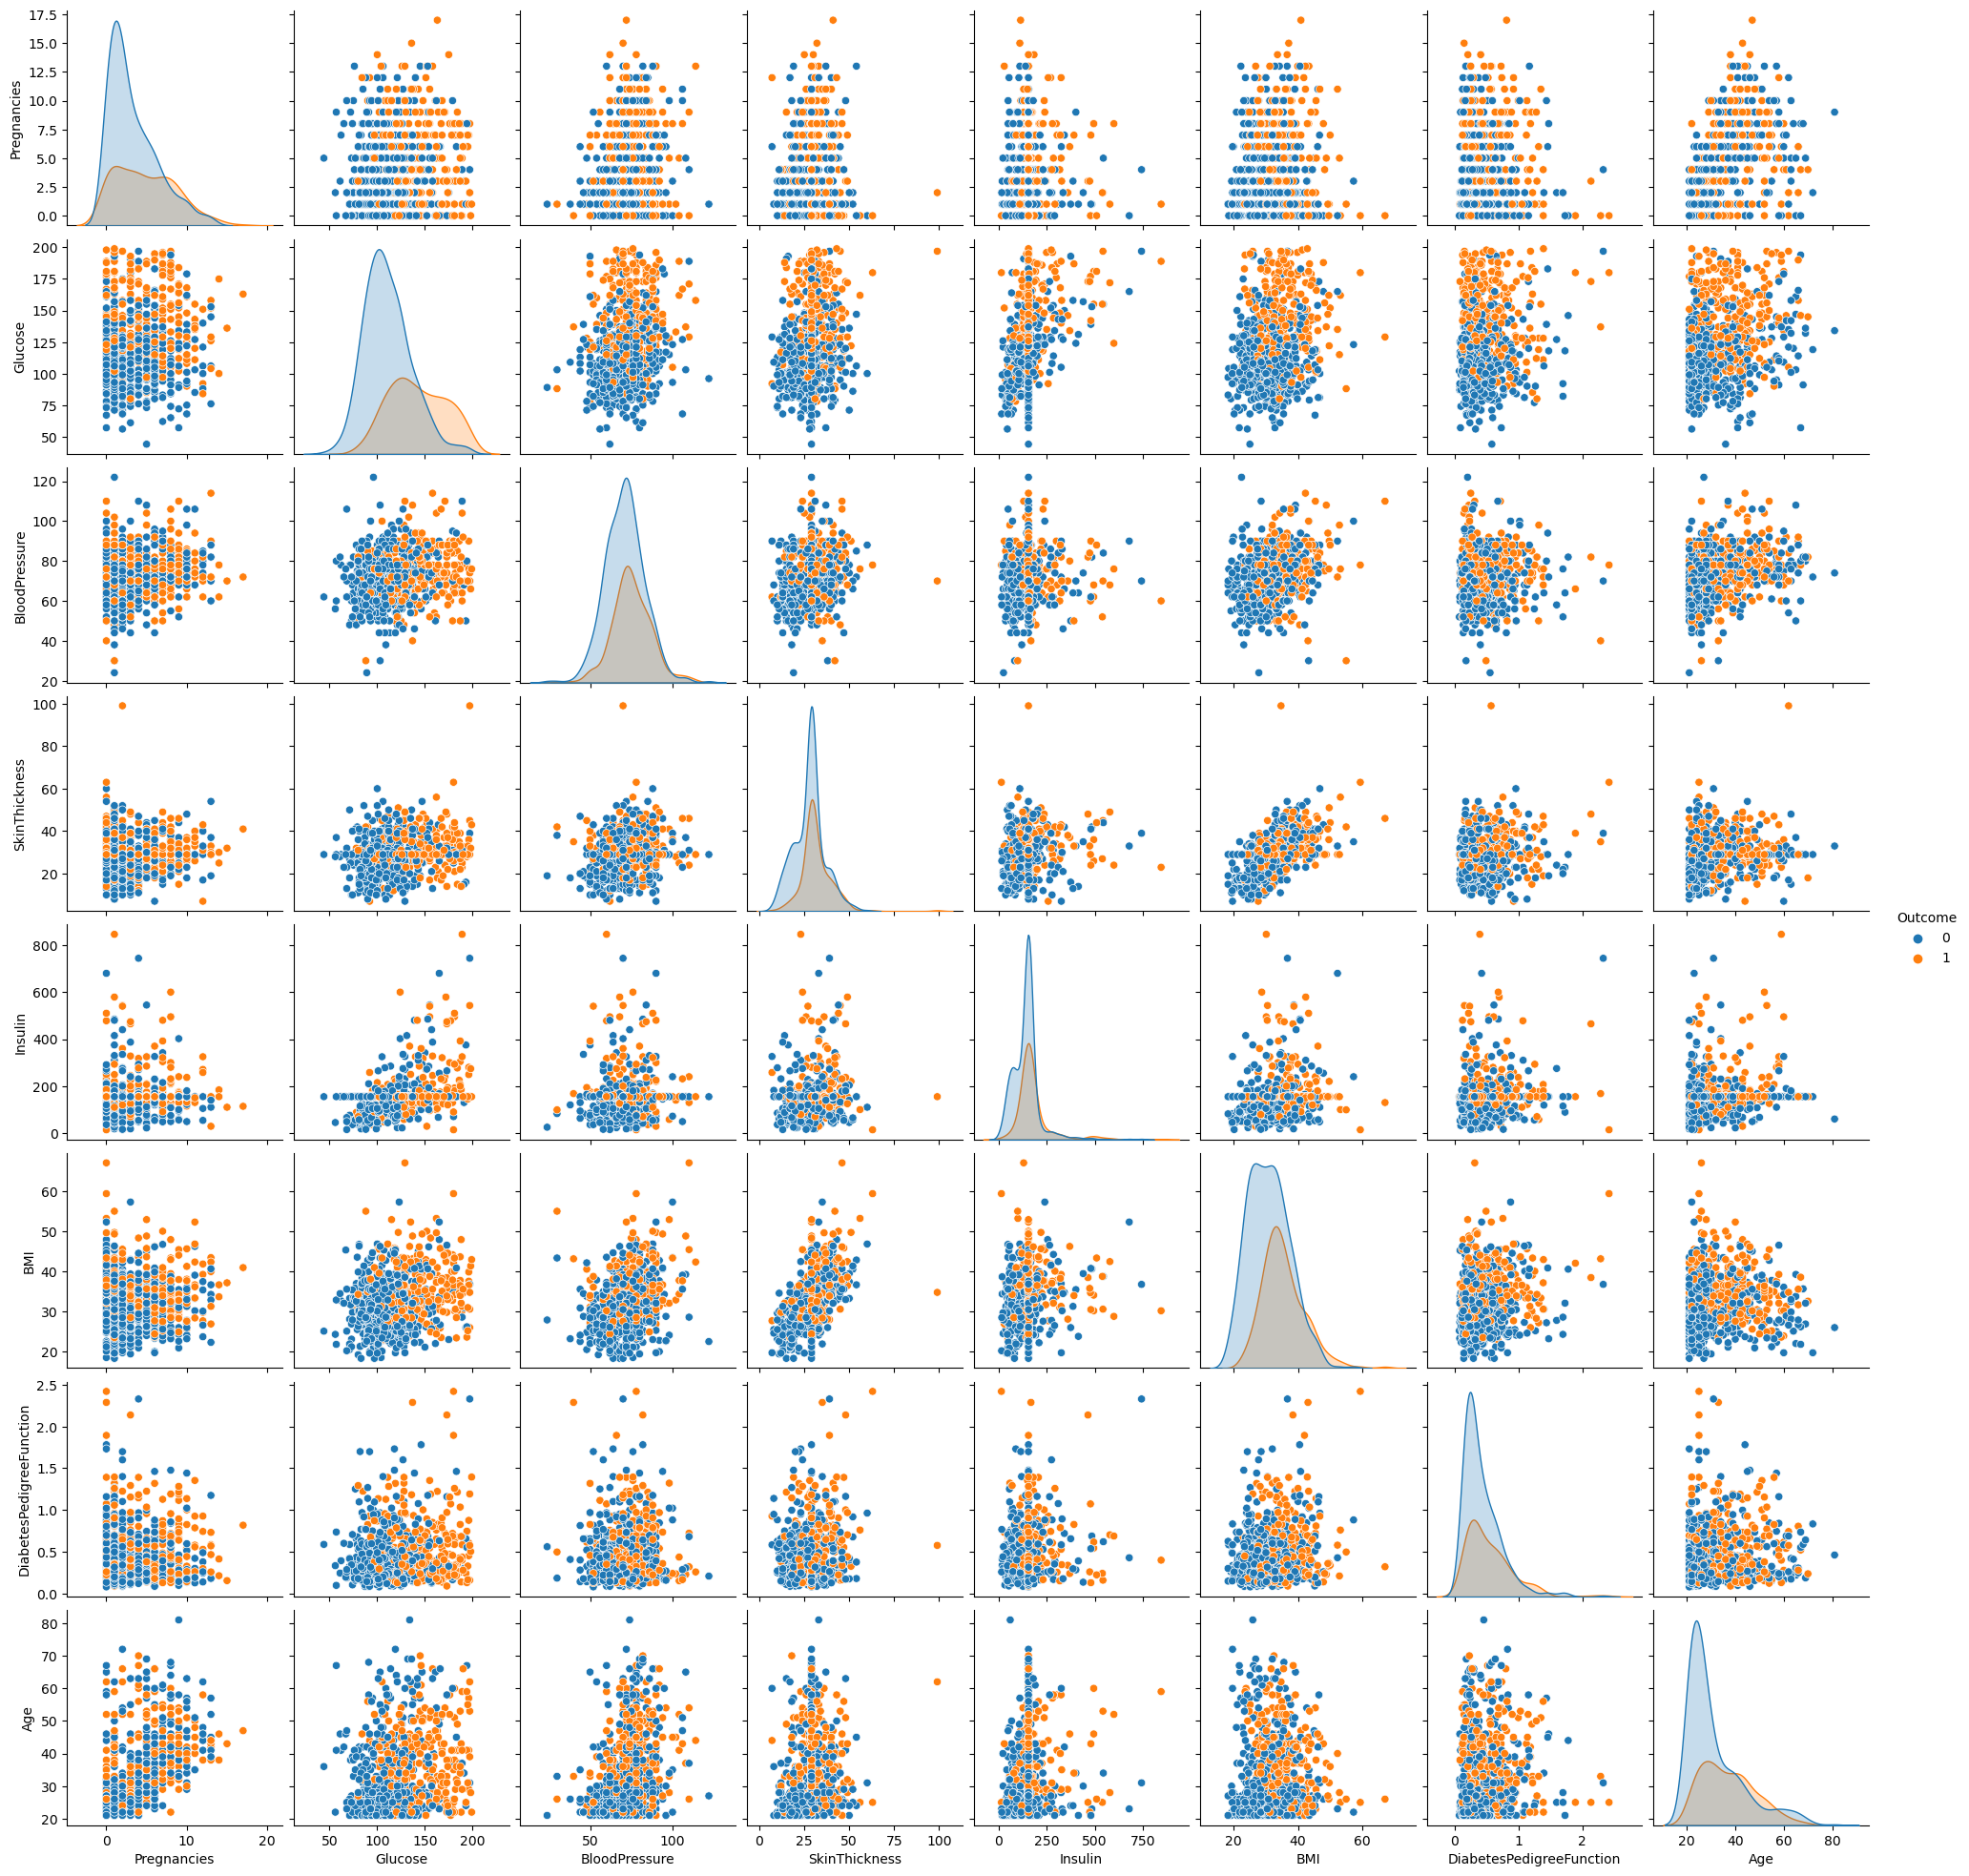

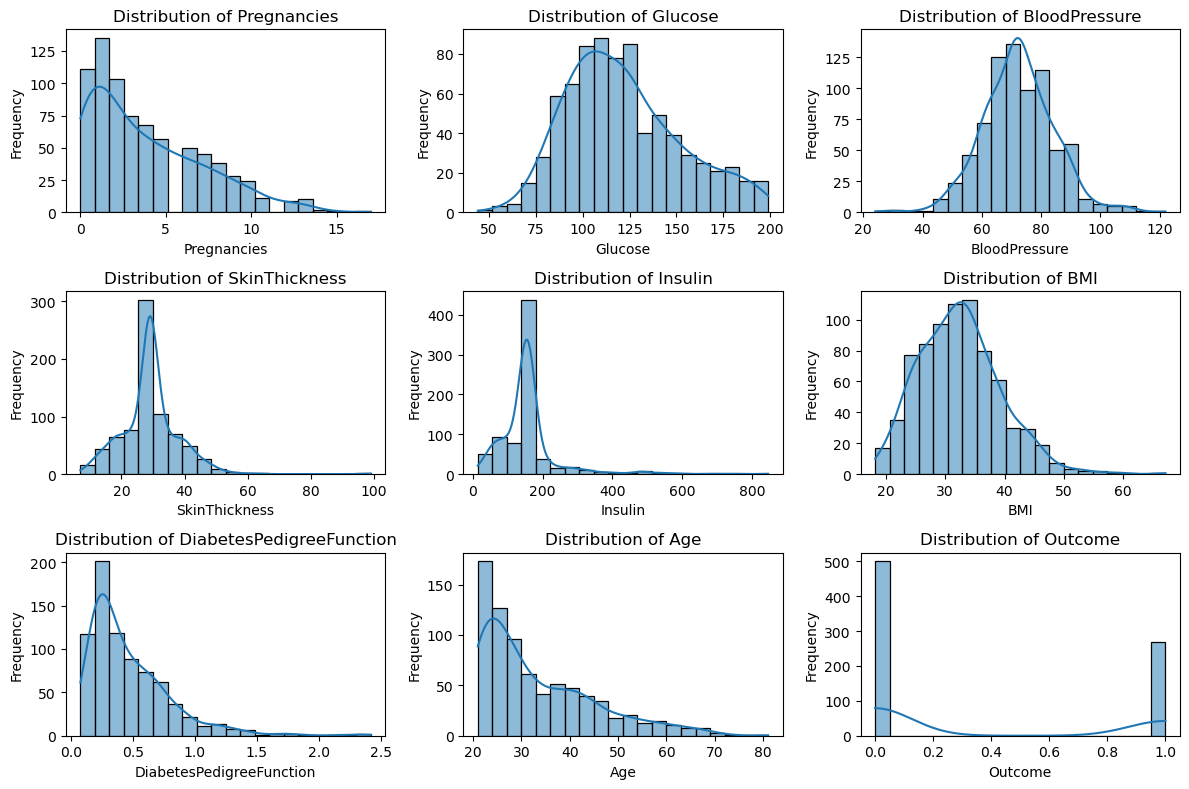

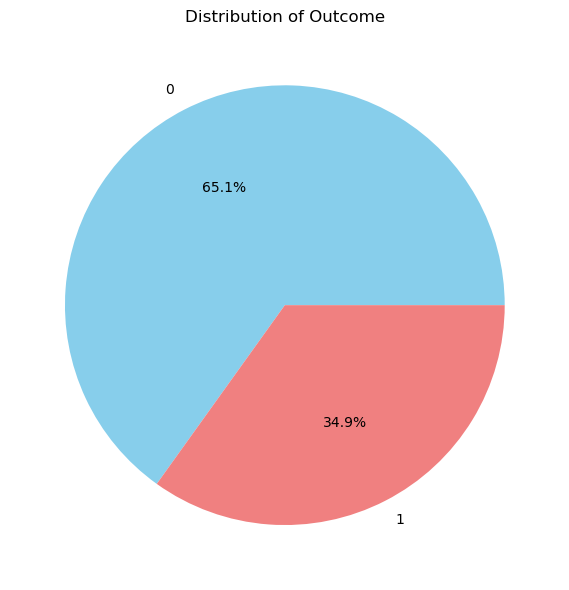

The model predicts that the individual has diabetes.
Enter Pregnancies: 6
Enter Glucose: 72
Enter BloodPressure: 78
Enter SkinThickness: 0.33
Enter Insulin: 0
Enter BMI: 0.33
Enter DiabetesPedigreeFunction: 36
Enter Age: 50
[1]
Confusion Matrix:
[[94 13]
 [15 32]]


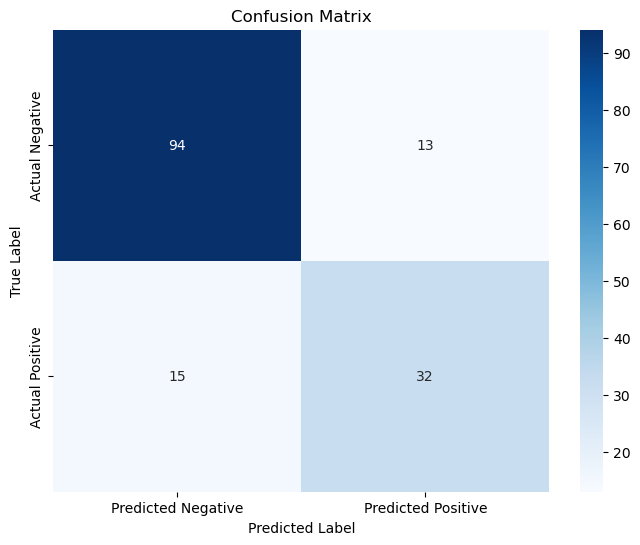

Accuracy: 0.8181818181818182
Precision: 0.7111111111111111
Recall: 0.6808510638297872
Sensitivity: 0.6808510638297872
Specificity: 0.8785046728971962
F1 Score: 0.6956521739130436


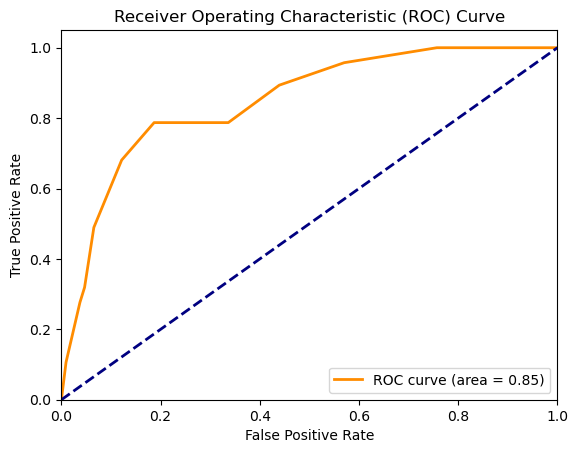

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

# Importing dataset
dataset = pd.read_csv('diabetes(1).csv')
print(len(dataset))
print(dataset.head())

# Replacing zeroes with the mean values
zero_not_accepted = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_not_accepted:
    dataset[col] = dataset[col].replace(0,np.NaN)
    mean = int(dataset[col].mean(skipna = True))
    dataset[col] = dataset[col].replace(np.NaN,mean)   
print(dataset['Glucose'])

# Exploring data to know relation before processing
sns.heatmap(dataset.corr())
plot.show()
plot.figure(figsize=(25,7))
sns.countplot(x='Age', hue='Outcome', data=dataset, palette='Set1')
plot.show()

# Create pairplot
p = sns.pairplot(dataset, hue='Outcome')

# Bar graphs for each column
plot.figure(figsize=(12, 8))
for i, column in enumerate(dataset.columns, 1):
    plot.subplot(3, 3, i)
    sns.histplot(dataset[column], bins=20, kde=True)
    plot.title(f'Distribution of {column}')
    plot.xlabel(column)
    plot.ylabel('Frequency')
plot.tight_layout()
plot.show()

# Pie charts for categorical variables
plot.figure(figsize=(12, 6))
categorical_columns = ['Outcome']  # Add more categorical columns if needed
for i, column in enumerate(categorical_columns, 1):
    plot.subplot(1, len(categorical_columns), i)
    dataset[column].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
    plot.title(f'Distribution of {column}')
    plot.ylabel('')
plot.tight_layout()
plot.show()


# Spliiting dataset into train and test
X = dataset.iloc[:,0:8]
Y = dataset.iloc[:,8]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=0,test_size=0.2)


# Feature of StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

# Define model -: Init KNN
len(Y)

import math
math.sqrt(len(Y_train))

# Training the dataset
knn = KNeighborsClassifier(n_neighbors=11,p=2,metric='euclidean')
classifier = knn.fit(X_train, Y_train)

# Predicting the set results
Y_pred = knn.predict(X_test)
Y_pred

# Example user input data
user_data = [[6, 148, 72, 35, 0, 33.6, 0.627, 50]]
sc_X = StandardScaler()
sc_X.fit(X_train)
user_data_standardized = sc_X.transform(user_data)
prediction = classifier.predict(user_data_standardized)
if prediction[0] == 0:
    print("The model predicts that the individual does not have diabetes.")
else:
    print("The model predicts that the individual has diabetes.")

    
# Interactive input
user_data = []
for feature in ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']:
    value = float(input(f"Enter {feature}: "))
    user_data.append(value)
user_data = [user_data]

print(prediction)

# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Visualizing confusion matrix using heatmap
plot.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plot.title('Confusion Matrix')
plot.xlabel('Predicted Label')
plot.ylabel('True Label')
plot.show()

# Performance Metrics
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_curve, auc
# Accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(Y_test, Y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(Y_test, Y_pred)
print("Recall:", recall)

# Sensitivity (Recall)
sensitivity = recall
print("Sensitivity:", sensitivity)

# Specificity
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
print("Specificity:", specificity)

# F1-score
f1 = f1_score(Y_test, Y_pred)
print("F1 Score:", f1)

# ROC curve
Y_pred_proba = classifier.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_proba)
roc_auc = auc(fpr, tpr)
plot.figure()
plot.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plot.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plot.xlim([0.0, 1.0])
plot.ylim([0.0, 1.05])
plot.xlabel('False Positive Rate')
plot.ylabel('True Positive Rate')
plot.title('Receiver Operating Characteristic (ROC) Curve')
plot.legend(loc="lower right")
plot.show()

DECISION TREE

Accuracy Score = 69.48051948051948 %
Precision Score = 0.5
Recall Score = 0.5319148936170213
F1 Score = 0.5154639175257731
Confusion Matrix =  [[82 25]
 [22 25]]


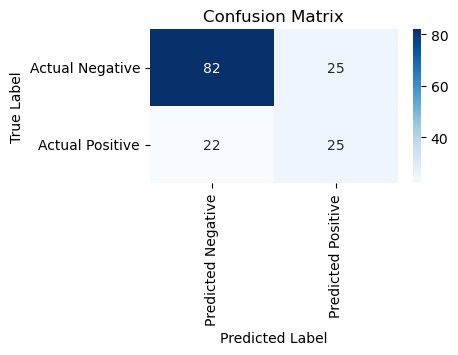

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
dtree = DecisionTreeClassifier(max_depth=14,random_state= 0)
dtree.fit(X_train, Y_train)

#Getting the accuracy score for Decision Tree

from sklearn import metrics

predictions = dtree.predict(X_test)
accuracy_DT = accuracy_score(Y_test,predictions)
precision_DT = precision_score(Y_test, predictions)
recall_DT = recall_score(Y_test, predictions)
f1_DT = f1_score(Y_test, predictions)
con_matrixdt= confusion_matrix(Y_test,predictions)
print("Accuracy Score =", accuracy_DT*100, "%")
print("Precision Score =", precision_DT)
print("Recall Score =", recall_DT)
print("F1 Score =", f1_DT)
print("Confusion Matrix = ",con_matrixdt)
# Visualizing confusion matrix using heatmap
plot.figure(figsize=(4, 2))
sns.heatmap(con_matrixdt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plot.title('Confusion Matrix')
plot.xlabel('Predicted Label')
plot.ylabel('True Label')
plot.show()

RANDOM FOREST

Total number of records:  768
Parameter are:  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


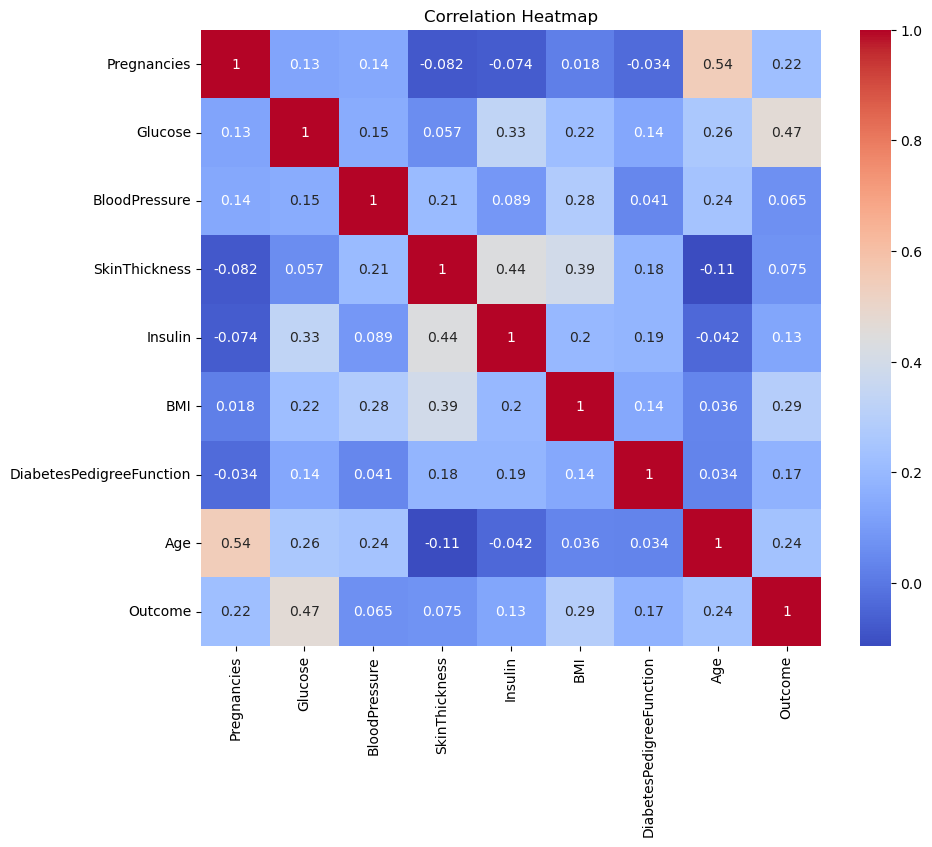

Ensemble Accuracy: 0.7792207792207793
Confusion Matrix:
[[139  18]
 [ 33  41]]


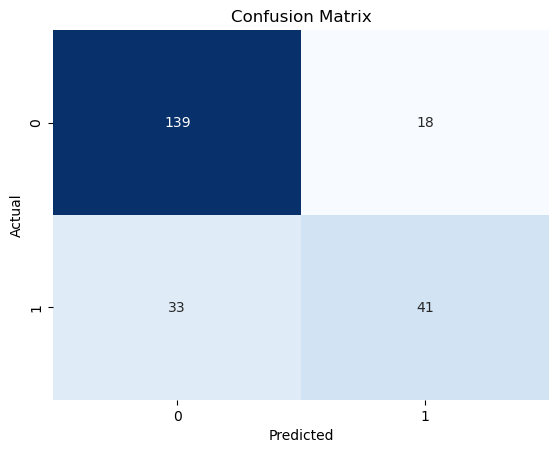

In [ ]:
import pandas as pd                                                        #for data manipulation
import numpy as np                                                         #for numerical operations
from matplotlib import pyplot as plt                                       #for visualization
import seaborn as sns                                                      #for visualization
from sklearn.ensemble import RandomForestClassifier                        #for using Random forest Classifier algorithm
from sklearn.metrics import accuracy_score                                 #for accouracy

df = pd.read_csv('diabetes(1).csv') #Read a CSV file by given path
df

print('Total number of records: ',len(df))                # For checking number of records

print("Parameter are: ",df.columns)                     #For printing coloumn names

df.info()                           #Get insight about data

df.describe()

df['Outcome'].describe()

plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

df.isnull().values.any()

true_count= len(df.loc[df['Outcome']==True])
False_count= len(df.loc[df['Outcome']==False])
(true_count,False_count)

df.corr()['Outcome'].sort_values()

from sklearn.model_selection import train_test_split
X = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
Y = df['Outcome']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3, random_state=0)

n_estimators = 10
base_models = []

for i in range(n_estimators):
    rf = RandomForestClassifier(n_estimators=200)
    rf.fit(X_train, Y_train)
    base_models.append(rf)
  
predictions = [model.predict(X_test) for model in base_models]

ensemble_predictions = np.round(np.mean(predictions, axis=0))

ensemble_accuracy = accuracy_score(Y_test, ensemble_predictions)
print(f"Ensemble Accuracy: {ensemble_accuracy}")

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(Y_test, ensemble_predictions)

# Display the confusion matrix
print("Confusion Matrix:")
print(confusion)


cm = confusion_matrix(Y_test, ensemble_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Get input from the user
user_input = {
    'Glucose': float(input('Enter Glucose level: ')),
    'BloodPressure': float(input('Enter Blood Pressure: ')),
    'SkinThickness': float(input('Enter Skin Thickness: ')),
    'Insulin': float(input('Enter Insulin level: ')),
    'BMI': float(input('Enter BMI: ')),
    'DiabetesPedigreeFunction': float(input('Enter Diabetes Pedigree Function: ')),
    'Age': float(input('Enter Age: '))
}

# Convert the user input into a DataFrame
user_df = pd.DataFrame([user_input])

# Make a prediction using the trained model
user_prediction = rf.predict(user_df)

# Interpret the prediction
if user_prediction[0] == 0:
    result = "No diabetes"
else:
    result = "Diabetes"

print(f"The model predicts: {result}")


    

SUPPORT VECTOR MACHINE

In [2]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Load dataset

df=pd.read_csv(r"diabetes(1).csv")
df

#summarize dataset
df.shape

df.info()

#check for null values.
df.isna().sum()

#check for duplicated rows
df.duplicated().sum()

#statistical analysis
df.describe()

#Exploratory data Analysis (EDA)
#no:of diabetic patients
df['Outcome'].value_counts()
# '0' represents non-diabetic peoples
# '1' represents diabetic peoples

#average sugar level for the diabetic and non-diabetic peoples
df.groupby('Outcome').mean()

#segregate dataset into x & y.
x=df.drop('Outcome',axis=1)
y=df['Outcome']
x

y

#Data Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_std=scaler.fit_transform(x)
x_std

#train test splitting 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_std,y,test_size=0.25,random_state=0)
print('x_train:',x_train.shape)
print('x_test:',x_test.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)

from sklearn import svm
from sklearn.metrics import accuracy_score
classifier=svm.SVC(kernel='linear')
#training the support vector machine classifier(SVM)
classifier.fit(x_train,y_train)

# Accuracy score on the training data
y_train_prediction=classifier.predict(x_train)
training_data_accuracy =accuracy_score(y_train_prediction,y_train)
print("Accuracy score of training data:",training_data_accuracy*100)

#Accuracy score on test data
y_test_prediction=classifier.predict(x_test)
testing_data_accuracy =accuracy_score(y_test_prediction,y_test)
print("Accuracy score of testing data:",testing_data_accuracy*100)

x.columns

x.head(2)

print("Hi, Welcome")
print("Please Enter the following details..")
a=int(input("Enter pregnancies: "))
b=int(input("Enter Glucose level: "))
c=int(input("Enter BloodPressure: "))
d=int(input("Enter SkinThickness: "))
e=int(input("Enter Insulin: "))
f=float(input("Enter BMI: "))
g=float(input("Enter DiabetesPedigreeFunction: "))
h=int(input("Enter Age: "))
k=[[a,b,c,d,e,f,g,h]]
k_std=scaler.fit_transform(k)
d_predict=classifier.predict(k_std)
if d_predict == 0:
    print("The person is non-diabetic.")
else:
    print("The person is diabetic, Please consult a doctor")
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
x_train: (576, 8)
x_test: (192, 8)
y_train: (576,)
y_test: (192,)
Accuracy score of training data: 76.38888888888889
Accuracy score of testing data: 80.20833333333334
Hi, Welcome
Please Enter the following details..
Enter pregnancies: 8
Ent